# SRCNN Training

## Objective

The goal of this notebook is to verify that the complete training pipeline works correctly.

The notebook performs:

- model initialization;
- DataLoader creation;
- loss definition;
- optimizer definition;
- execution of one training epoch.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import torch
import torch.nn as nn

from src.models.srcnn import SRCNN
from src.dataloader import get_train_loader
from src.train import train_one_epoch
from src.config import LEARNING_RATE, NUM_EPOCHS

## Device

Select the device used for training.

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## DataLoader

In [4]:
train_loader = get_train_loader()

## Model

In [5]:
model = SRCNN().to(device)

print(model)

SRCNN(
  (feature_extraction): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): ReLU(inplace=True)
  )
  (mapping): Sequential(
    (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
  )
  (reconstruction): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


## Loss Function

In [6]:
criterion = nn.MSELoss()

## Optimizer

In [7]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

## One Training Epoch

In [8]:
TRAIN_EPOCHS = 200

loss_history = []

for epoch in range(TRAIN_EPOCHS):

    loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    loss_history.append(loss)

    print(f"Epoch {epoch + 1}/{TRAIN_EPOCHS} - Loss: {loss:.6f}")

Epoch 1/200 - Loss: 0.127450
Epoch 2/200 - Loss: 0.017831
Epoch 3/200 - Loss: 0.011459
Epoch 4/200 - Loss: 0.007880
Epoch 5/200 - Loss: 0.006145
Epoch 6/200 - Loss: 0.005253
Epoch 7/200 - Loss: 0.004541
Epoch 8/200 - Loss: 0.003898
Epoch 9/200 - Loss: 0.003645
Epoch 10/200 - Loss: 0.003376
Epoch 11/200 - Loss: 0.003057
Epoch 12/200 - Loss: 0.002710
Epoch 13/200 - Loss: 0.002595
Epoch 14/200 - Loss: 0.002515
Epoch 15/200 - Loss: 0.002373
Epoch 16/200 - Loss: 0.002488
Epoch 17/200 - Loss: 0.002256
Epoch 18/200 - Loss: 0.002293
Epoch 19/200 - Loss: 0.002306
Epoch 20/200 - Loss: 0.002284
Epoch 21/200 - Loss: 0.002152
Epoch 22/200 - Loss: 0.002206
Epoch 23/200 - Loss: 0.002069
Epoch 24/200 - Loss: 0.001940
Epoch 25/200 - Loss: 0.001967
Epoch 26/200 - Loss: 0.001992
Epoch 27/200 - Loss: 0.001863
Epoch 28/200 - Loss: 0.001873
Epoch 29/200 - Loss: 0.001881
Epoch 30/200 - Loss: 0.001938
Epoch 31/200 - Loss: 0.001863
Epoch 32/200 - Loss: 0.001796
Epoch 33/200 - Loss: 0.001952
Epoch 34/200 - Loss

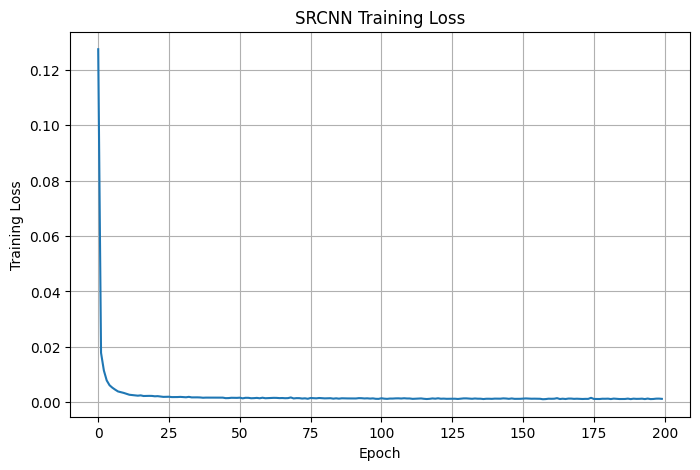

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("SRCNN Training Loss")

plt.grid(True)

plt.show()

In [10]:
import json

with open("../results/metrics/srcnn_x2_200epochs_loss.json", "w") as f:
    json.dump(loss_history, f)

print("Loss history saved.")

Loss history saved.


In [13]:
from src.checkpoint import save_model
save_model(
    model,
    "../results/checkpoints/srcnn_x2_200epochs.pth"
)

In [15]:
from src.checkpoint import load_model
model = load_model(
    model,
    "../results/checkpoints/srcnn_x2_200epochs.pth",
    device
)

c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)
